# Hands-On Perception Project: Side Scan Sonar Loop Closure

#### Juan Castillo
#### Max Puig
#### David Villanueva

# 1) Define data paths 

In [1]:
import torch 
import cv2 
import os 
import numpy as np 
from pathlib import Path

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') # Define GPU device

# For data preparation
input_dir = r'data'     # XTF file folder
output_dir = r'output'  # Output dataset folder
segment_size = 2000
overlap_size = 1000
upper_limit = 2 ** 15

# For inference
test_image_path = r'output/images'
test_range_path = r'output/range'
test_altitude_path = r'output/altitude'
weight_path = r'best_model_v610_eagle.pth'     # Select the best weights for inference
# weight_path = r'best_model_v610_jaguar.pth'
# weight_path = r'best_model_v611_jaguar.pth'
output_inf = r'output/visual_test' # Result saving path

# For terrain mask generation
altitude_dir = r"output/altitude"
range_dir = r"output/range"
depth_dir = r"output/visual_test/z_gray" # Predicted height map
height_output_dir = r"output/visual_test/height_visual" # Store the grayscale image of the generated height map and the mask of its understated terrain areas.
output_folder = r"output/visual_test/z_mask"

# 2) Run PhysDepth 

## 2.1) Prepare data

##### Takes the xtf files and separates the waterfall into different images according to the segment size and overlap size. Stores the images, range, altitude and shadow in the output folder, as well as blind masks for both channels

In [27]:
# The images are saved into the output folder
from physdnet.prep import prepare_data
prepare_data(input_dir, output_dir, segment_size, overlap_size, upper_limit, 'both')
prepare_data(input_dir, output_dir, segment_size, overlap_size, upper_limit, 'left')
prepare_data(input_dir, output_dir, segment_size, overlap_size, upper_limit, 'right')

Processing file: 2025-09-24_09-25-24_0.xtf
	Number of blind bins: 680
Mask calculated!
mask_left: (2000, 2000), mask_right: (2000, 2000)
left channel data shape (72675, 2000)
left channel data shape 145350000


[ WARN:0@3863.676] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


2025-09-24_09-25-24_0.xtf: total_rows=72675, segments=72, stride=1000
Processing file: 2025-09-24_09-25-24_0.xtf
	Number of blind bins: 680
Mask calculated!
mask_left: (2000, 2000), mask_right: (2000, 2000)
left channel data shape (72675, 2000)
left channel data shape 145350000
2025-09-24_09-25-24_0.xtf: total_rows=72675, segments=72, stride=1000
Processing file: 2025-09-24_09-25-24_0.xtf
	Number of blind bins: 680
Mask calculated!
mask_left: (2000, 2000), mask_right: (2000, 2000)
left channel data shape (72675, 2000)
left channel data shape 145350000
2025-09-24_09-25-24_0.xtf: total_rows=72675, segments=72, stride=1000


## 2.2) Run inference

##### This generates the inference for z, z_gray (elevation normal and grayed), rho, rho_gray (range normal and grayed), path loss, theta, phi and shadow in the output folder

In [3]:
from physdnet.test import run_inference
run_inference(device, test_image_path, test_range_path, test_altitude_path, weight_path, output_inf, 'left')
run_inference(device, test_image_path, test_range_path, test_altitude_path, weight_path, output_inf, 'right')
run_inference(device, test_image_path, test_range_path, test_altitude_path, weight_path, output_inf, 'both')

Image saved to: output_left/visual_test/theta/2025-09-24_09-25-24_0.xtf_left_069_theta.png
Image saved to: output_left/visual_test/z/2025-09-24_09-25-24_0.xtf_left_069_z.png
Image saved to: output_left/visual_test/path/2025-09-24_09-25-24_0.xtf_left_069_path.png
Image saved to: output_left/visual_test/rho/2025-09-24_09-25-24_0.xtf_left_069_rho.png
Image saved to: output_left/visual_test/theta/2025-09-24_09-25-24_0.xtf_left_070_theta.png
Image saved to: output_left/visual_test/z/2025-09-24_09-25-24_0.xtf_left_070_z.png
Image saved to: output_left/visual_test/path/2025-09-24_09-25-24_0.xtf_left_070_path.png
Image saved to: output_left/visual_test/rho/2025-09-24_09-25-24_0.xtf_left_070_rho.png
Image saved to: output_left/visual_test/theta/2025-09-24_09-25-24_0.xtf_left_044_theta.png
Image saved to: output_left/visual_test/z/2025-09-24_09-25-24_0.xtf_left_044_z.png
Image saved to: output_left/visual_test/path/2025-09-24_09-25-24_0.xtf_left_044_path.png
Image saved to: output_left/visual_te

In [7]:
# Both channels
total_images = len(os.listdir(test_image_path))
print(f"Total test images for both channels: {total_images}")

# Left channel
total_images = len(os.listdir(test_image_path.replace("output", "output_left")))
print(f"Total test images for left channel: {total_images}")

# Right channel
total_images = len(os.listdir(test_image_path.replace("output", "output_right")))
print(f"Total test images for right channel: {total_images}")

Total test images for both channels: 144
Total test images for left channel: 72
Total test images for right channel: 72


## 2.3) Terrain masks

#### Generates masks for elevation and shadow for feature filtering and saves the result in height_visual and z_mask


In [8]:
from physdnet.terrain_mask import terrain_mask
terrain_mask(altitude_dir, range_dir, depth_dir, height_output_dir, output_folder, "left")
terrain_mask(altitude_dir, range_dir, depth_dir, height_output_dir, output_folder, "right")
terrain_mask(altitude_dir, range_dir, depth_dir, height_output_dir, output_folder, "both")

100%|██████████| 72/72 [00:00<00:00, 120.20it/s]


Processing complete


100%|██████████| 72/72 [00:00<00:00, 117.84it/s]


Processing complete


100%|██████████| 144/144 [00:01<00:00, 118.21it/s]


Processing complete


## 3) Run MINIMA on the left side for feature matching and straction

### Combine masks for outlier rejection, use shadow map, blind zone, and height map

In [2]:
def combine_masks(*mask_paths, output_path):
    '''Combines multiple binary masks into one by taking the union of their valid areas.'''
    masks = [cv2.imread(path, cv2.IMREAD_GRAYSCALE) for path in mask_paths]

    shape = masks[0].shape # All masks should have the same shape as the first mask
    for i, mask in enumerate(masks):
        if mask.shape != shape:
            masks[i] = cv2.resize(mask, (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)

    combined_mask = (sum(mask > 0 for mask in masks) > 0).astype(np.uint8) * 255

    cv2.imwrite(output_path, combined_mask)

def prepare_mask(mask: torch.Tensor, device):
    mask = mask.to(device)

    if mask.dim() == 3:
        # if RGB, take one channel
        mask = mask[0]

    # binary: 1 invalid, 0 valid
    mask = (mask > 0.5).to(torch.uint8)
    return mask

def filter_matches_with_masks(kpts0, kpts1, mask0, mask1):
    '''Applies a mask to a set of keypoints'''
    # Gets the device
    device = kpts0.device

    # Threshold the masks from int to bool
    mask0 = prepare_mask(mask0, device)
    mask1 = prepare_mask(mask1, device)

    # Gets the mask dimensions
    H0, W0 = mask0.shape
    H1, W1 = mask1.shape

    # Extract the keypoints coordinates
    x0i = torch.round(kpts0[:, 0]).long()
    y0i = torch.round(kpts0[:, 1]).long()
    x1i = torch.round(kpts1[:, 0]).long()
    y1i = torch.round(kpts1[:, 1]).long()

    inside0 = (x0i >= 0) & (x0i < W0) & (y0i >= 0) & (y0i < H0)
    inside1 = (x1i >= 0) & (x1i < W1) & (y1i >= 0) & (y1i < H1)

    valid0 = torch.zeros_like(inside0, dtype=torch.bool)
    valid1 = torch.zeros_like(inside1, dtype=torch.bool)

    valid0[inside0] = (mask0[y0i[inside0], x0i[inside0]] == 0)
    valid1[inside1] = (mask1[y1i[inside1], x1i[inside1]] == 0)

    keep = valid0 & valid1
    return kpts0[keep], kpts1[keep]

# For the left side only
shadow_mask_path =  r"output_left/shadow"
z_mask_path =  r"output_left/visual_test/z_mask"
blind_mask = Path(r"output_left/2025-09-24_09-25-24_0.xtf_mask_left.png")

# Get all the files, they should be the same number, one per image
shadow_mask_files = [f for f in os.listdir(shadow_mask_path) if f.lower().endswith('.png')]
z_mask_files = [f for f in os.listdir(z_mask_path) if f.lower().endswith('.png')]

# Generate all the masks by combining the shadow mask, z mask, and blind mask
masks_output = r"output_left/final_masks"
os.makedirs(masks_output, exist_ok=True)
i = 0
for shadow_file, z_mask_file in zip(shadow_mask_files, z_mask_files):
    shadow_i_path = os.path.join(shadow_mask_path, shadow_file)
    z_i_path = os.path.join(z_mask_path, z_mask_file)
    output_i = os.path.join(masks_output, f"mask_{i}.png")
    combine_masks(z_i_path, shadow_i_path, blind_mask,output_path=output_i)
    # combine_masks(shadow_i_path, blind_mask,output_path=output_i)
    # combine_masks(blind_mask, output_path=output_i)
    i += 1

#### Match a pair of images and visualize the results

In [3]:
def warp_and_overlay(
    img_ref: np.ndarray,
    img_to_warp: np.ndarray,
    H: np.ndarray,
    alpha: float = 0.1,
) -> np.ndarray:
    """
    Warp img_to_warp into the frame of img_ref using H and create a canvas
    large enough to show both images entirely.

    H must map points from img_to_warp -> img_ref.
    """
    h_ref, w_ref = img_ref.shape[:2]
    h_warp, w_warp = img_to_warp.shape[:2]

    # Corners of both images
    corners_ref = np.array([
        [0, 0],
        [w_ref, 0],
        [w_ref, h_ref],
        [0, h_ref]
    ], dtype=np.float32).reshape(-1, 1, 2)

    corners_warp = np.array([
        [0, 0],
        [w_warp, 0],
        [w_warp, h_warp],
        [0, h_warp]
    ], dtype=np.float32).reshape(-1, 1, 2)

    # Warp corners of img_to_warp into img_ref coordinates
    warped_corners = cv2.perspectiveTransform(corners_warp, H)

    # Combine all corners to find full canvas bounds
    all_corners = np.vstack((corners_ref, warped_corners)).reshape(-1, 2)

    x_min, y_min = np.floor(all_corners.min(axis=0)).astype(int)
    x_max, y_max = np.ceil(all_corners.max(axis=0)).astype(int)

    # Translation to shift everything into positive canvas coordinates
    tx = -x_min
    ty = -y_min

    T = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ], dtype=np.float64)

    out_w = x_max - x_min
    out_h = y_max - y_min

    # Warp the moving image into the new canvas
    warped = cv2.warpPerspective(img_to_warp, T @ H, (out_w, out_h))

    # Place reference image into the same canvas
    canvas_ref = np.zeros((out_h, out_w, 3), dtype=img_ref.dtype)
    canvas_ref[ty:ty + h_ref, tx:tx + w_ref] = img_ref

    # Overlay
    overlay = cv2.addWeighted(canvas_ref, alpha, warped, 1 - alpha, 0)

    return overlay

['2025-09-24_09-25-24_0.xtf_left_030_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_034_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_004_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_007_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_045_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_066_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_017_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_021_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_002_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_044_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_023_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_059_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_000_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_027_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_038_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_061_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_069_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_039_rho_gray.png', '2025-09-24_09-25-24_0.xtf_left_064_rho_gray.png', '2025-09-24_09-25-24_0.xtf_lef

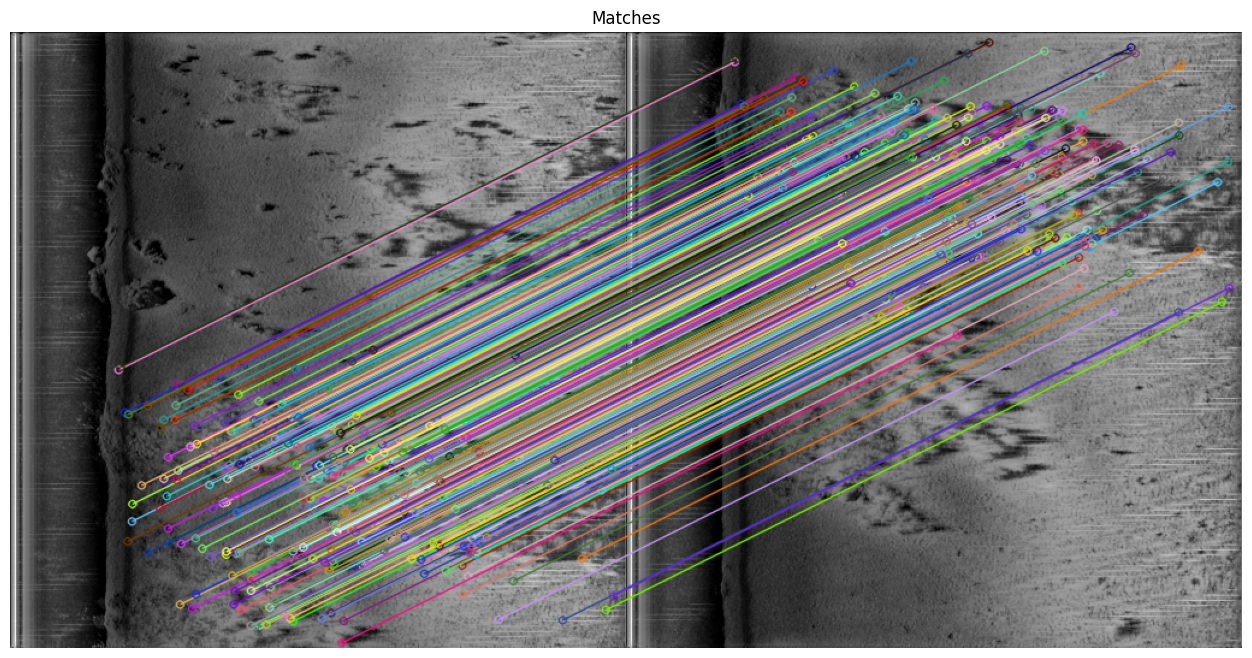

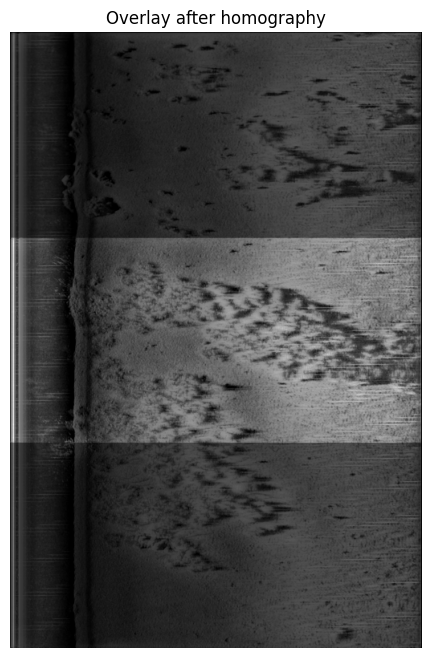

In [ ]:
from minima_pipeline import MatchResult, MinimaMatcher, run_pipeline_on_images, draw_matches
import matplotlib.pyplot as plt

i,j = 60, 61 # Pair of images to test

# Build matcher for in-memory images
matcher = MinimaMatcher(method="sp_lg", ckpt="MINIMA/weights/minima_lightglue.pth", use_path=False)

raw_images_path = r"output_left/visual_test/rho_gray"
raw_images = [f for f in os.listdir(raw_images_path) if f.lower().endswith('.png')]
raw_images.sort(key=lambda s: int(s.split('_')[-3].split('.')[0]))

# Get the first two images, since they are consecutive, there should be a lot of matches
# These images are then aligned one with another to confirm the homography is correct
img0 = cv2.imread(os.path.join(raw_images_path, raw_images[i]))
img1 = cv2.imread(os.path.join(raw_images_path, raw_images[j]))

print(f"Testing matching between {raw_images[i]} and {raw_images[j]}")

# Your binary masks, same size as each image
raw_masks_path = r"output_left/final_masks"
raw_masks = [f for f in os.listdir(raw_masks_path) if f.lower().endswith('.png')]
raw_masks.sort(key=lambda s: int(s.split('_')[-1].split('.')[0]))
mask0 = cv2.imread(os.path.join(raw_masks_path, raw_masks[i]), cv2.IMREAD_GRAYSCALE)
mask1 = cv2.imread(os.path.join(raw_masks_path, raw_masks[j]), cv2.IMREAD_GRAYSCALE)

print(f"Taking masks {raw_masks[i]} and {raw_masks[j]}")

# Get the result from the matcher between the two images
result = run_pipeline_on_images(
    matcher,
    img0,
    img1,
    mask0=mask0,
    mask1=mask1,
    ransac_reproj_threshold=8.0,
    ransac_max_iters=10_000,
    ransac_confidence=0.995
)

# Draws the matches
vis = draw_matches(img0, img1, result.mkpts0_kept, result.mkpts1_kept, result.ransac_inliers)

print("Raw matches:", len(result.mkpts0))
print("After mask filtering:", len(result.mkpts0_kept))
print("RANSAC inliers:", 0 if result.ransac_inliers is None else int(result.ransac_inliers.sum()))
print("Homography:\n", result.H)

vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 8))
plt.imshow(vis_rgb)
plt.axis("off")
plt.title("Matches")
plt.show()

overlay = warp_and_overlay(img1, img0, result.H, alpha=0.5)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Overlay after homography")
plt.show()

# 4) Calculate transacts indices

#### Estimate indices of the trajectory that correspond to the transacts. First, plot the trajectory and the pings every 50 samples

---------------------
FileFormat: 123
SystemType: 1
RecordingProgramName: b'IQUA'
RecordingProgramVersion: b'100'
SonarName: b'ScoutMkII_ros'
SonarType: 44
NoteString: b'Marine Sonic Technology Corp.'
ThisFileName: b'/home/user/logs/mk_ii/2025-09-24_09-25-24_0.xtf'
NavUnits: 3
NumberOfSonarChannels: 2
NumberOfBathymetryChannels: 0
NumberOfSnippetChannels: 0
NumberOfForwardLookArrays: 0
NumberOfEchoStrengthChannels: 0
NumberOfInterferometryChannels: 0
Reserved1: 0
Reserved2: 0
ReferencePointHeight: 0.0
ProjectionType: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SpheriodType: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
NavigationLatency: 0
OriginY: 0.0
OriginX: 0.0
NavOffsetY: 0.0
NavOffsetX: 0.0
NavOffsetZ: 0.0
NavOffsetYaw: 0.0
MRUOffsetY: 0.0
MRUOffsetX: 0.0
MRUOffsetZ: 0.0
MRUOffsetYaw: 0.0
MRUOffsetPitch: 0.0
MRUOffsetRoll: 0.0
ChanInfo: [<pyxtf.xtf_ctypes.XTFChanInfo object at 0x779a7ab642d0>, <pyxtf.xtf_ctypes.XTFChanInfo object at 0x7799774fa650>, <pyxtf.xtf_ctypes.XTFChanInfo object at 0x7799774fa6

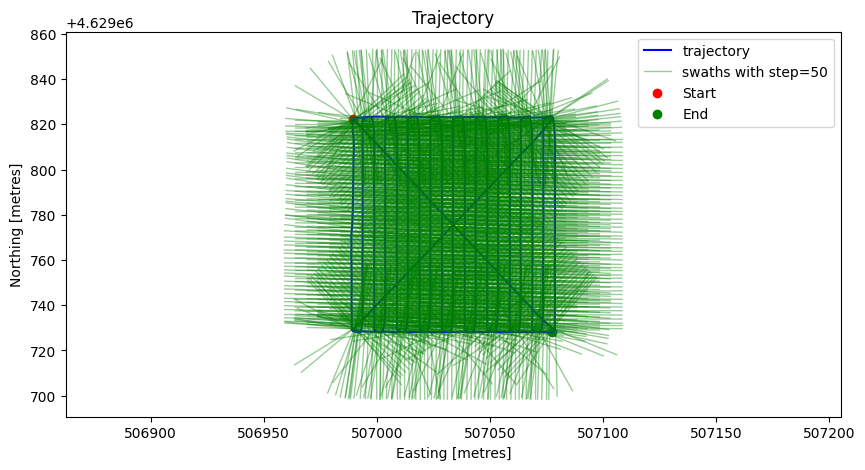

In [5]:
import physdnet.xtf_utils as xtf_utils
import matplotlib.pyplot as plt 

data_load = xtf_utils.load_xtf(r"/home/david/Documents/IFRoS/Perception/HoP-SSS-Loop-Closure/data/2025-09-24_09-25-24_0.xtf")
swaths, trajectory, altitude, roll, pitch, yaw = xtf_utils.calculate_swath_positions(data_load)

_, ax = plt.subplots(figsize=(10,5))

# Plot trajectory
ax.plot(trajectory[:,0], trajectory[:,1], color="blue", label="trajectory")

# Plot ping lines 
step = 50
for i in range(0, swaths.shape[0], step):
    start_point = swaths[i, 0, :]      
    end_point = swaths[i, -1, :]       
    
    x_vals = [start_point[0], end_point[0]]
    y_vals = [start_point[1], end_point[1]]
    
    if i == 0:
        ax.plot(x_vals, y_vals, color='green', linestyle='-', alpha=0.4, linewidth=1, label=f"swaths with step={step}")
    else:    
        ax.plot(x_vals, y_vals, color='green', linestyle='-', alpha=0.4, linewidth=1)

ax.axis("equal")
ax.set_title("Trajectory")
ax.set_xlabel("Easting [metres]")
ax.set_ylabel("Northing [metres]")
ax.axis("equal")
ax.scatter([trajectory[0,0]], [trajectory[0,1]], label="Start", c="red")
ax.scatter([trajectory[-1,0]], [trajectory[-1,1]], label="End", c="green")
ax.legend()

plt.show()

#### Get the yaw from the graph, apply an exponential low pass filter and calculate the numerical derivative

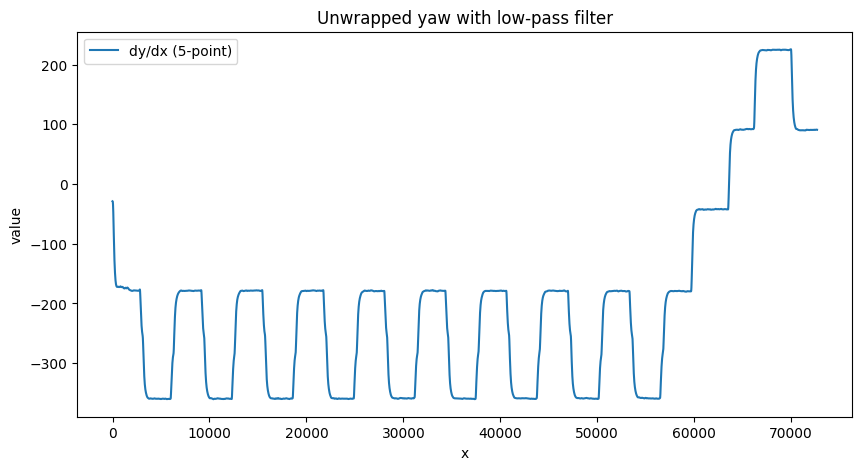

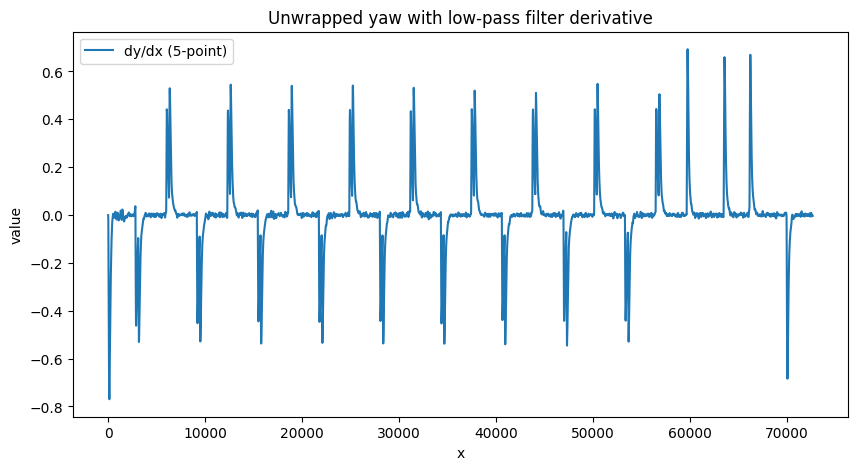

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def numerical_derivative_5point(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length")
    if len(x) < 5:
        raise ValueError("Need at least 5 points")

    h = x[1] - x[0]
    if not np.allclose(np.diff(x), h):
        raise ValueError("This 5-point formula assumes equally spaced x values")

    dydx = np.empty_like(y)

    # Forward 5-point formula for first two points
    dydx[0] = (-25*y[0] + 48*y[1] - 36*y[2] + 16*y[3] - 3*y[4]) / (12*h)
    dydx[1] = (-3*y[0] - 10*y[1] + 18*y[2] - 6*y[3] + y[4]) / (12*h)

    # Central 5-point formula for interior points
    for i in range(2, len(y) - 2):
        dydx[i] = (y[i-2] - 8*y[i-1] + 8*y[i+1] - y[i+2]) / (12*h)

    # Backward 5-point formula for last two points
    dydx[-2] = (-y[-5] + 6*y[-4] - 18*y[-3] + 10*y[-2] + 3*y[-1]) / (12*h)
    dydx[-1] = (3*y[-5] - 16*y[-4] + 36*y[-3] - 48*y[-2] + 25*y[-1]) / (12*h)

    return dydx
def lowpass_and_derivative_5point(x, y, alpha=0.2):
    """
    Applies a simple low-pass filter first, then computes the numerical
    derivative using a 5-point finite-difference stencil.

    Parameters
    ----------
    x : array-like
        Equally spaced x values.
    y : array-like
        Signal values.
    alpha : float
        Low-pass filter coefficient in (0, 1].
        Smaller -> stronger smoothing.

    Returns
    -------
    y_filt : np.ndarray
        Low-pass filtered signal.
    dydx : np.ndarray
        Numerical derivative of filtered signal.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length")
    if len(x) < 5:
        raise ValueError("Need at least 5 points")

    h = x[1] - x[0]
    if not np.allclose(np.diff(x), h):
        raise ValueError("This 5-point formula assumes equally spaced x values")

    if not (0 < alpha <= 1):
        raise ValueError("alpha must be in the range (0, 1]")

    # Low-pass filter: exponential smoothing
    y_filt = np.empty_like(y)
    y_filt[0] = y[0]
    for i in range(1, len(y)):
        y_filt[i] = alpha * y[i] + (1 - alpha) * y_filt[i - 1]

    # 5-point derivative
    dydx = np.empty_like(y_filt)

    # Forward formulas
    dydx[0] = (-25*y_filt[0] + 48*y_filt[1] - 36*y_filt[2] + 16*y_filt[3] - 3*y_filt[4]) / (12*h)
    dydx[1] = (-3*y_filt[0] - 10*y_filt[1] + 18*y_filt[2] - 6*y_filt[3] + y_filt[4]) / (12*h)

    # Central formula
    for i in range(2, len(y_filt) - 2):
        dydx[i] = (y_filt[i - 2] - 8*y_filt[i - 1] + 8*y_filt[i + 1] - y_filt[i + 2]) / (12*h)

    # Backward formulas
    dydx[-2] = (-y_filt[-5] + 6*y_filt[-4] - 18*y_filt[-3] + 10*y_filt[-2] + 3*y_filt[-1]) / (12*h)
    dydx[-1] = (3*y_filt[-5] - 16*y_filt[-4] + 36*y_filt[-3] - 48*y_filt[-2] + 25*y_filt[-1]) / (12*h)

    return y_filt, dydx

filter, dy = lowpass_and_derivative_5point(np.arange(len(np.unwrap(yaw)*180/np.pi)), np.unwrap(yaw)*180/np.pi, 0.01)

_, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(len(np.unwrap(yaw)*180/np.pi)), filter, label="dy/dx (5-point)")
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.legend()
ax.set_title("Unwrapped yaw with low-pass filter")
plt.show()

_, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(len(np.unwrap(yaw)*180/np.pi)), dy, label="dy/dx (5-point)")
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.legend()
ax.set_title("Unwrapped yaw with low-pass filter derivative")
plt.show()


#### Get the groups that correspond to straight transacts

Count of groups:  30


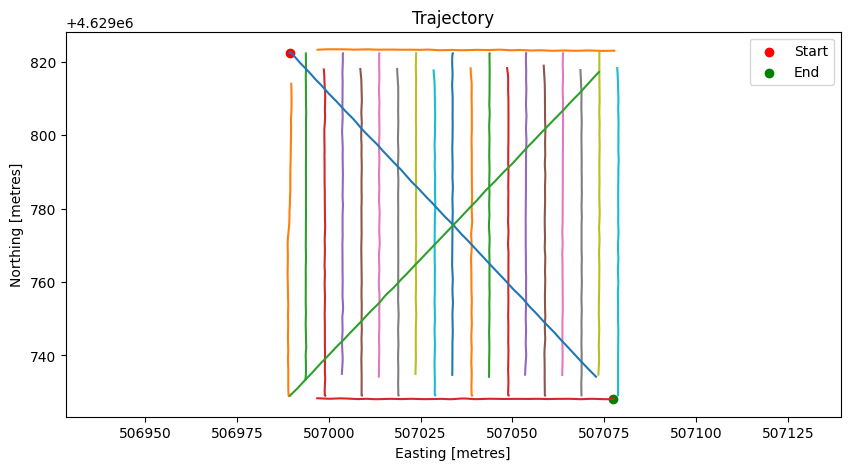

In [10]:
# Threshold the derivative to find where 
threshold = 0.08
Ids = np.where(np.abs(dy)>threshold)[0]
new_index = range(0, swaths.shape[0],1)
new_index = np.delete(new_index,Ids)

# Detect different groups after removing turns
changes = 1
jumps = np.where(np.diff(new_index) > changes)[0] + 1
groups = np.split(new_index, jumps)

# Preserve only large groups
min_group_size = 26
groups_indexes = [g for g in groups if len(g) > min_group_size]

print("Count of groups: ", len(groups))
max_values = [np.max(i) for i in groups_indexes]

# Plot the trajectory with different colors for each group
_, ax = plt.subplots(figsize=(10,5))
for i in range(len(groups_indexes)):
    minimum = min(groups_indexes[i])
    maximum = max(groups_indexes[i])
    ax.plot(trajectory[minimum:maximum,0], trajectory[minimum:maximum,1])

ax.axis("equal")
ax.set_title("Trajectory")
ax.set_xlabel("Easting [metres]")
ax.set_ylabel("Northing [metres]")
ax.axis("equal")
ax.scatter([trajectory[0,0]], [trajectory[0,1]], label="Start", c="red")
ax.scatter([trajectory[-1,0]], [trajectory[-1,1]], label="End", c="green")
ax.legend()

plt.show()

# 5) Extract transact images